<a href="https://colab.research.google.com/github/Dhruv-kys/TORCH-NOTEBOOK/blob/main/Neural-Networks-NN_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Model init

In [5]:
## Create model class

import torch
import torch.nn as nn

class Model(nn.Module):
  def __init__(self,num_features):

    super().__init__()
    self.linear = nn.Linear(num_features,1)
    self.sigmoid = nn.Sigmoid()

  def forward(self,features):
    out = self.linear(features)
    out = self.sigmoid(out)

    return out


### Dataset

In [6]:
# create dataset
features = torch.rand(10,5)

# create model
model = Model(features.shape[1])

# forward pass
model(features)

tensor([[0.4465],
        [0.4730],
        [0.5223],
        [0.4527],
        [0.4770],
        [0.4560],
        [0.4343],
        [0.4420],
        [0.4120],
        [0.4783]], grad_fn=<SigmoidBackward0>)

In [9]:
# model weights
model.linear.weight


Parameter containing:
tensor([[-0.1868, -0.3857,  0.2154, -0.3045, -0.0538]], requires_grad=True)

### NN Visualization

In [10]:
!pip install torchinfo

In [11]:
from torchinfo import summary

summary(model, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Linear: 1-1                            [10, 1]                   6
├─Sigmoid: 1-2                           [10, 1]                   --
Total params: 6
Trainable params: 6
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

## NN with Hidden layer

In [13]:
## Create model class

import torch
import torch.nn as nn

class Model(nn.Module):
  def __init__(self,num_features):

    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(num_features,3),
        nn.ReLU(),
        nn.Linear(3,1),
        nn.Sigmoid()
    )

  def forward(self,features):
    out = self.network(features)

    return out


In [15]:
features = torch.rand(10,5)
model = Model(features.shape[1])
model(features)

tensor([[0.4175],
        [0.3857],
        [0.3668],
        [0.3881],
        [0.3986],
        [0.3790],
        [0.3999],
        [0.3805],
        [0.3918],
        [0.4135]], grad_fn=<SigmoidBackward0>)

In [16]:
from torchinfo import summary

summary(model, input_size=(10,5))

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [10, 1]                   --
├─Sequential: 1-1                        [10, 1]                   --
│    └─Linear: 2-1                       [10, 3]                   18
│    └─ReLU: 2-2                         [10, 3]                   --
│    └─Linear: 2-3                       [10, 1]                   4
│    └─Sigmoid: 2-4                      [10, 1]                   --
Total params: 22
Trainable params: 22
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [17]:
!pip install torchviz

In [18]:
from torchviz import make_dot

# Create a dummy input tensor matching the model's expected input_size
dummy_input = torch.rand(10, 5)

# Perform a forward pass to get the computation graph
output = model(dummy_input)

# Generate the visualization graph
dot = make_dot(output, params=dict(model.named_parameters()))

# You can save the graph to a file (e.g., PDF, PNG) or display it directly
# To display it directly in Colab, you need graphviz installed and possibly rendered as SVG
# For simplicity, let's render to a file and then display it if possible, or just print the dot object.

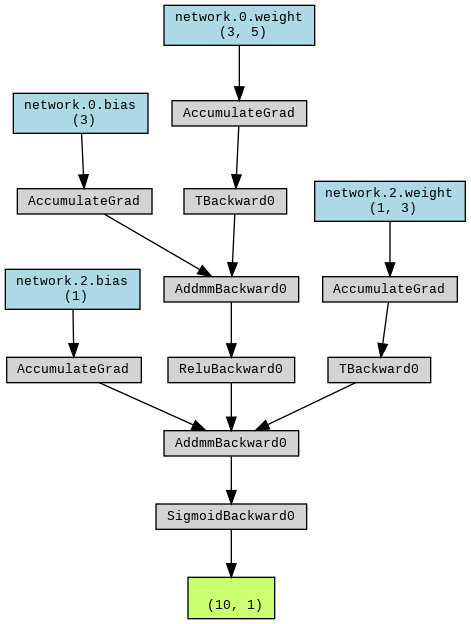

In [19]:
# To display the graph directly in Colab, you can use dot.render() and then display the image.
# Ensure graphviz is installed in the Colab environment for this to work.
# By default, make_dot requires graphviz to render. It's usually pre-installed or can be installed with apt-get.

# Save the graph to a file and display it (e.g., as PNG)
dot.render('model_architecture', format='png', cleanup=True)

# Display the image in Colab
from IPython.display import Image
Image('model_architecture.png')